In [1]:
pip install torch torchvision matplotlib

In [2]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),                # converts to tensor in [0,1]
    transforms.Normalize((0.1307,), (0.3081,))  # standard MNIST mean and std
])


In [4]:
train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 40.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.06MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.83MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]


In [5]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [6]:
images, labels = next(iter(train_loader))
print(images.shape)  # should be [64, 1, 28, 28]
print(labels.shape)  # should be [64]


torch.Size([64, 1, 28, 28])
torch.Size([64])


In [7]:
class LinearMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(28 * 28, 10)  # 10 classes

    def forward(self, x):
        x = self.flatten(x)       # [batch, 1, 28,28] -> [batch, 784]
        logits = self.fc(x)       # [batch, 10]
        return logits


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_stack = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),  # [B, 1, 28, 28] -> [B, 16, 28, 28]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                                   # -> [B, 16, 14, 14]

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1), # -> [B, 32, 14, 14]
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                                     # -> [B, 32, 7, 7]
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                            # [B, 32,7,7] -> [B, 32*7*7]
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_stack(x)
        x = self.classifier(x)
        return x


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# model = LinearMNIST().to(device)
model = SimpleCNN().to(device)


Using device: cpu


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [11]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)           # [B,10]
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # compute accuracy
        _, preds = torch.max(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [12]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [13]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}")


Epoch 1/5 Train Loss: 0.1553 Acc: 0.9533 Test Loss: 0.0522 Acc: 0.9820
Epoch 2/5 Train Loss: 0.0495 Acc: 0.9848 Test Loss: 0.0386 Acc: 0.9874
Epoch 3/5 Train Loss: 0.0353 Acc: 0.9892 Test Loss: 0.0338 Acc: 0.9891
Epoch 4/5 Train Loss: 0.0269 Acc: 0.9913 Test Loss: 0.0321 Acc: 0.9891
Epoch 5/5 Train Loss: 0.0224 Acc: 0.9925 Test Loss: 0.0291 Acc: 0.9909


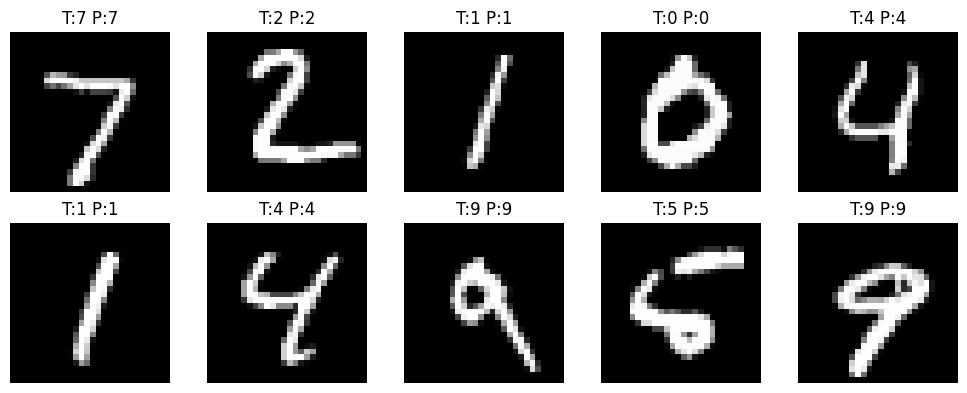

In [18]:
def show_some_predictions(model, dataloader, device, num_images=10):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(10, 4))

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)

            for i in range(images.size(0)):
                if images_shown >= num_images:
                    plt.tight_layout()
                    plt.show()
                    return

                img = images[i].cpu().squeeze(0)  # [1,28,28] -> [28,28]
                label = labels[i].item()
                pred = preds[i].item()

                plt.subplot(2, num_images // 2, images_shown + 1)
                plt.imshow(img, cmap="gray")
                plt.title(f"T:{label} P:{pred}")
                plt.axis("off")
                images_shown += 1

show_some_predictions(model, test_loader, device)
